In [1]:
# ============================================================
# Scripts 4.20–4.22 (Updated): Heisenberg Hamiltonian Builder
# ============================================================
from qiskit.quantum_info import SparsePauliOp

def get_hamiltonian_n_site_terms(n, coeff, n_qubits):
    """
    Membangun terms Hamiltonian untuk pasangan site ke-n dan ke-(n+1).
    
    SparsePauliOp menerima string Pauli, misalnya:
    n=0, n_qubits=3 → 'IXX' artinya: XX bekerja di qubit 0-1, I di qubit 2
    
    PERHATIAN: Qiskit menggunakan konvensi LITTLE-ENDIAN untuk Pauli strings!
    String 'IXX' → qubit 0 mendapat X paling kanan, dst.
    Jadi urutan karakter TERBALIK dari notasi matematika konvensional!
    """
    XX_coeff = coeff[0]
    YY_coeff = coeff[1]
    ZZ_coeff = coeff[2]
    Z_coeff  = coeff[3]

    # 'I'*n + 'XX' + 'I'*(n_qubits-2-n): padding dengan identitas
    # Catatan: Qiskit Pauli strings dibaca dari RIGHT ke LEFT untuk qubit index
    XX_term = SparsePauliOp('I'*n + 'XX' + 'I'*(n_qubits-2-n)) * XX_coeff
    YY_term = SparsePauliOp('I'*n + 'YY' + 'I'*(n_qubits-2-n)) * YY_coeff
    ZZ_term = SparsePauliOp('I'*n + 'ZZ' + 'I'*(n_qubits-2-n)) * ZZ_coeff
    Z_term  = SparsePauliOp('I'*n + 'Z'  + 'I'*(n_qubits-1-n)) * Z_coeff

    return (XX_term + YY_term + ZZ_term + Z_term).simplify()


def get_heisenberg_hamiltonian(n_qubits, coeff=None):
    """
    Membangun Hamiltonian Heisenberg N-site dengan memisahkan
    terms genap (even) dan ganjil (odd).
    
    Pemisahan ini PENTING untuk Trotterisasi:
    - Terms genap (site 0-1, 2-3, ...): commute satu sama lain
    - Terms ganjil (site 1-2, 3-4, ...): commute satu sama lain
    - Tapi even TIDAK commute dengan odd → perlu Trotter approximation
    
    Analogi: seperti memisahkan "tim merah" dan "tim biru" yang tidak bisa
    bekerja bersamaan, tapi dalam tim yang sama bisa paralel.
    """
    assert n_qubits >= 3

    if coeff is None:
        coeff = [[1.0, 1.0, 1.0, 1.0] for _ in range(n_qubits)]

    # Even terms: site (0,1), (2,3), ...
    H_E = sum(get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
              for i in range(0, n_qubits-1, 2))

    # Odd terms: site (1,2), (3,4), ...
    H_O = sum(get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
              for i in range(1, n_qubits-1, 2))

    # Final Z term di site terakhir
    final_term = SparsePauliOp('I'*(n_qubits-1) + 'Z') * coeff[n_qubits-1][3]

    if n_qubits % 2 == 0:
        H_E = (H_E + final_term).simplify()
    else:
        H_O = (H_O + final_term).simplify()

    return [H_E, H_O]


# --- Test untuk sistem 3 spin ---
num_q = 3
# Koefisien dari Table 1 paper: [XX/2, YY/2, ZZ, Z] per site
ham_coeffs = (
    [[0.75/2, 0.75/2, 0.0, 0.65]]       # site 0: coupling khusus
    + [[0.5, 0.5, 0.0, 1.0]] * (num_q-1) # site 1,2: coupling default
)

spin_chain_H = get_heisenberg_hamiltonian(num_q, ham_coeffs)
H_total = sum(spin_chain_H)
print("Hamiltonian even + odd terms:")
for i, h in enumerate(spin_chain_H):
    print(f"  H_{['even','odd'][i]}:", h)
print("\nH total:", H_total)

Hamiltonian even + odd terms:
  H_even: SparsePauliOp(['XXI', 'YYI', 'ZII'],
              coeffs=[0.375+0.j, 0.375+0.j, 0.65 +0.j])
  H_odd: SparsePauliOp(['IXX', 'IYY', 'IZI', 'IIZ'],
              coeffs=[0.5+0.j, 0.5+0.j, 1. +0.j, 1. +0.j])

H total: SparsePauliOp(['XXI', 'YYI', 'ZII', 'IXX', 'IYY', 'IZI', 'IIZ'],
              coeffs=[0.375+0.j, 0.375+0.j, 0.65 +0.j, 0.5  +0.j, 0.5  +0.j, 1.   +0.j,
 1.   +0.j])


In [2]:
# ============================================================
# Script 4.23 (Updated): Trotterized Time Evolution Operator
# ============================================================
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter  # Qiskit 2.x: dari qiskit.synthesis

def get_time_evolution_operator(num_qubits, tau, trotter_steps, coeff=None):
    """
    Membangun operator evolusi waktu dengan Suzuki-Trotter decomposition.
    
    Pipeline:
    1. Bangun Hamiltonian H sebagai SparsePauliOp
    2. Bungkus dalam PauliEvolutionGate(H, t, synthesis=SuzukiTrotter)
    3. Qiskit otomatis kompilasi menjadi circuit gates
    
    SuzukiTrotter(order=2): second-order (symmetric) Trotter
    Lebih akurat dari order=1 dengan error O(δt²) vs O(δt)
    """
    heisenberg_H = get_heisenberg_hamiltonian(num_qubits, coeff)

    # PauliEvolutionGate: gate untuk e^{-iHt}
    # synthesis: algoritma untuk dekomposisi ke gates primitif
    evo_op = PauliEvolutionGate(
        heisenberg_H,
        tau,
        synthesis=SuzukiTrotter(order=2, reps=trotter_steps)
    )
    return evo_op.definition  # mengembalikan QuantumCircuit


num_q             = 3
evolution_timestep = 0.1
n_trotter_steps    = 1

time_evo_op = get_time_evolution_operator(
    num_qubits=num_q,
    tau=evolution_timestep,
    trotter_steps=n_trotter_steps,
    coeff=ham_coeffs
)

print("Time Evolution Operator Circuit:")
print(time_evo_op.draw(output='text'))
print(f"Circuit depth: {time_evo_op.depth()}")

Time Evolution Operator Circuit:
                                     ┌───────────┐┌───────────┐┌─────────┐»
q_0: ────────────────────────────────┤0          ├┤0          ├┤ Rz(0.2) ├»
     ┌──────────────┐┌──────────────┐│  Rxx(0.1) ││  Ryy(0.1) │├─────────┤»
q_1: ┤0             ├┤0             ├┤1          ├┤1          ├┤ Rz(0.2) ├»
     │  Rxx(0.0375) ││  Ryy(0.0375) │├───────────┤└───────────┘└─────────┘»
q_2: ┤1             ├┤1             ├┤ Rz(0.065) ├────────────────────────»
     └──────────────┘└──────────────┘└───────────┘                        »
«                                                  
«q_0: ─────────────────────────────────────────────
«     ┌──────────────┐┌──────────────┐             
«q_1: ┤0             ├┤0             ├─────────────
«     │  Rxx(0.0375) ││  Ryy(0.0375) │┌───────────┐
«q_2: ┤1             ├┤1             ├┤ Rz(0.065) ├
«     └──────────────┘└──────────────┘└───────────┘
Circuit depth: 8


In [4]:
# ============================================================
# Scripts 4.24–4.28: Manual Trotterisasi (Compact Version)
# ============================================================
import re
from itertools import groupby
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister

def find_string_pattern(pattern, string):
    """Cari semua posisi match regex dalam string."""
    return [m.start() for m in re.finditer(pattern, string)]


def sort_Pauli_by_symmetry(ham):
    """
    Pisahkan terms Hamiltonian menjadi:
    - 1-qubit terms (Z rotations)
    - 2-qubit even terms (XX,YY,ZZ di pasangan (0,1), (2,3), ...)
    - 2-qubit odd terms (XX,YY,ZZ di pasangan (1,2), (3,4), ...)
    
    Analogi: seperti kasir toko yang memisahkan barang berdasarkan
    kelompok rak: minuman, makanan ringan, dst.
    """
    one_qubit_terms = []
    two_qubit_terms = []

    for term in ham:
        pauli_string = term.paulis[0]
        coeff        = np.real(term.coeffs[0])
        label        = pauli_string.to_label()  # contoh: 'IXX'
        matches      = find_string_pattern('X|Y|Z', label)
        str_tag      = label.replace('I', '')   # contoh: 'XX'

        if len(matches) == 2:
            two_qubit_terms.append((pauli_string, coeff, matches, str_tag))
        elif len(matches) == 1:
            one_qubit_terms.append((pauli_string, coeff, matches, str_tag))

    two_qubit_terms = sorted(two_qubit_terms, key=lambda x: x[2])

    # Pisah even/odd berdasarkan index qubit pertama
    even_tq = [x for x in two_qubit_terms if not x[2][0] % 2]
    odd_tq  = [x for x in two_qubit_terms if     x[2][0] % 2]

    # Group by qubit index (supaya XX,YY,ZZ untuk site yang sama jadi satu grup)
    even_tq = [list(v) for _, v in groupby(even_tq, key=lambda x: x[2][0])]
    odd_tq  = [list(v) for _, v in groupby(odd_tq,  key=lambda x: x[2][0])]

    return one_qubit_terms, even_tq, odd_tq


def generate_circ_pattern_1qubit(circ, term, delta_t):
    """
    Implementasi e^{-i·coeff·σ·dt} sebagai rotation gate.
    
    Dari identitas: e^{-iθ/2 · X} = Rx(θ), dan θ = 2*coeff*dt
    
    Analogi: memutar spin 1 qubit seperti memutar jarum jam
    dengan kecepatan dan arah yang ditentukan oleh koefisien.
    """
    angle  = 2 * term[1] * delta_t
    qubit  = term[2][0]   # index qubit target

    if   term[3] == 'X': circ.rx(angle, qubit)
    elif term[3] == 'Y': circ.ry(angle, qubit)
    elif term[3] == 'Z': circ.rz(angle, qubit)
    return circ


def generate_circ_pattern_2qubit(circ, term, delta_t):
    """
    Implementasi e^{-i(αXX + βYY + γZZ)dt} menggunakan dekomposisi optimal U(4).
    
    Menggunakan identitas N(α,β,γ) = exp{i(αXX + βYY + γZZ)}:
    θ = π/2 - 2γdt,  ϕ = 2αdt - π/2,  λ = π/2 - 2βdt
    
    Circuit pattern: RZ → CNOT → RZ → RY → CNOT → RY → CNOT → RZ
    Ini adalah dekomposisi OPTIMAL: hanya butuh 3 CNOT untuk 2-qubit interaction.
    
    Analogi: seperti cara paling efisien menyeberang sungai dengan jembatan
    yang terbatas — 3 jembatan (CNOT) adalah minimum yang diperlukan.
    """
    wires = term[0][2]  # [qubit_i, qubit_j]

    # Hitung sudut berdasarkan koefisien interaksi
    g_phi    = (2 * (-1) * term[0][1] * delta_t - np.pi/2) if any('XX' in s for s in term) else -np.pi/2
    g_lambda = (np.pi/2 - 2*(-1)*term[1][1]*delta_t)       if any('YY' in s for s in term) else  np.pi/2
    g_theta  = (np.pi/2 - 2*(-1)*term[2][1]*delta_t)       if any('ZZ' in s for s in term) else  np.pi/2

    # Circuit pattern untuk N(α,β,γ)
    circ.rz(-np.pi/2, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(g_theta,  wires[0])
    circ.ry(g_phi,    wires[1])
    circ.cx(wires[0], wires[1])
    circ.ry(g_lambda, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(np.pi/2,  wires[0])
    return circ


def get_manual_Trotter(num_q, pauli_ops, timestep, n_trotter=1,
                       trotter_type='basic', reverse_bits=True):
    """
    Manual Trotterisasi untuk Hamiltonian Pauli.
    
    Basic Trotter (BCA):   [even_2q] → [odd_2q] → [1q]
    Symmetric Trotter:     [1q/2] → [odd_2q/2] → [even_2q] → [odd_2q/2] → [1q/2]
    
    Symmetric lebih akurat (error O(dt²) bukan O(dt)) tapi lebih dalam circuitnya.
    """
    one_q, even_two_q, odd_two_q = sort_Pauli_by_symmetry(pauli_ops)

    dt_e = dt_o = dt_1 = timestep / n_trotter
    if trotter_type == 'symmetric':
        dt_o /= 2
        dt_1 /= 2

    # Bangun sub-circuits untuk tiap kelompok
    qc_e = QuantumCircuit(num_q)
    qc_o = QuantumCircuit(num_q)
    qc_1 = QuantumCircuit(num_q)

    for group in even_two_q:
        qc_e = generate_circ_pattern_2qubit(qc_e, group, dt_e)
    for group in odd_two_q:
        qc_o = generate_circ_pattern_2qubit(qc_o, group, dt_o)
    for term in one_q:
        qc_1 = generate_circ_pattern_1qubit(qc_1, term, dt_1)

    # Assembling
    qc = QuantumCircuit(QuantumRegister(num_q))
    if trotter_type == 'basic':
        qc = qc.compose(qc_e).compose(qc_o).compose(qc_1)
    elif trotter_type == 'symmetric':
        qc = qc.compose(qc_1).compose(qc_o).compose(qc_e).compose(qc_o).compose(qc_1)

    # Ulangi sebanyak n_trotter kali
    base_qc = qc.copy()
    for _ in range(n_trotter - 1):
        qc = qc.compose(base_qc)

    return qc.reverse_bits() if reverse_bits else qc


# Test manual Trotter
spin_chain_H_total = sum(get_heisenberg_hamiltonian(num_q, ham_coeffs))
manual_trotter_qc  = get_manual_Trotter(num_q, spin_chain_H_total, 0.1)

print("Manual Trotter Circuit (basic, 1 step):")
print(manual_trotter_qc.draw(output='text'))
print(f"Circuit depth: {manual_trotter_qc.depth()} gates")

Manual Trotter Circuit (basic, 1 step):
      ┌──────────┐                                                       »
q0_0: ┤ Rz(-π/2) ├─────────────────────────────────────────────────■─────»
      ├──────────┤     ┌─────────────┐┌───┐┌────────────┐        ┌─┴─┐   »
q0_1: ┤ Rz(-π/2) ├──■──┤ Ry(-1.6458) ├┤ X ├┤ Ry(1.6458) ├──■─────┤ X ├───»
      └──────────┘┌─┴─┐└─┬─────────┬─┘└─┬─┘└────────────┘┌─┴─┐┌──┴───┴──┐»
q0_2: ────────────┤ X ├──┤ Rz(π/2) ├────■────────────────┤ X ├┤ Rz(π/2) ├»
                  └───┘  └─────────┘                     └───┘└─────────┘»
«      ┌─────────────┐┌───┐┌────────────┐     ┌─────────┐           
«q0_0: ┤ Ry(-1.6708) ├┤ X ├┤ Ry(1.6708) ├──■──┤ Rz(0.2) ├───────────
«      └─┬─────────┬─┘└─┬─┘└────────────┘┌─┴─┐├─────────┤┌─────────┐
«q0_1: ──┤ Rz(π/2) ├────■────────────────┤ X ├┤ Rz(π/2) ├┤ Rz(0.2) ├
«        ├─────────┴┐                    └───┘└─────────┘└─────────┘
«q0_2: ──┤ Rz(0.13) ├───────────────────────────────────────────────
«        └──────────┘

In [5]:
# ============================================================
# Scripts 4.29–4.34 (Updated): Circuit Init & Statevector Sim
# ============================================================

# --- Inisialisasi State |011⟩ = |↑↓↓⟩ ---
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

qr = QuantumRegister(num_q, name='q')
cr = ClassicalRegister(num_q, name='c')
qc = QuantumCircuit(qr, cr)

# Metode 1: Bit-flip manual
for qubit_idx in range(num_q):
    if qubit_idx == 0:
        qc.id(qubit_idx)   # qubit-0: spin-up (|0⟩), biarkan
    else:
        qc.x(qubit_idx)    # qubit-1,2: flip ke |1⟩ (spin-down)
qc.barrier()

print("Initial circuit (bit-flip method):")
print(qc.draw(output='text'))


# --- Verifikasi initial state ---
from qiskit.quantum_info import Statevector

sv_init = Statevector(qc)
print("\nInitial statevector:")
print(sv_init)

# Konstruksi manual state |↑↓↓⟩ untuk verifikasi
zero_state = np.array([[1],[0]])
one_state  = np.array([[0],[1]])
psin0 = zero_state
for _ in range(num_q-1):
    psin0 = np.kron(psin0, one_state)
psin0 = psin0.flatten()
print(f"\nState |↑↓↓⟩ manual: {np.round(psin0, 4)}")

Initial circuit (bit-flip method):
     ┌───┐ ░ 
q_0: ┤ I ├─░─
     ├───┤ ░ 
q_1: ┤ X ├─░─
     ├───┤ ░ 
q_2: ┤ X ├─░─
     └───┘ ░ 
c: 3/════════
             

Initial statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j,
             0.+0.j],
            dims=(2, 2, 2))

State |↑↓↓⟩ manual: [0 0 0 1 0 0 0 0]


Menjalankan 250 langkah dinamika spin chain...
  Step 0/250
  Step 50/250
  Step 100/250
  Step 150/250
  Step 200/250


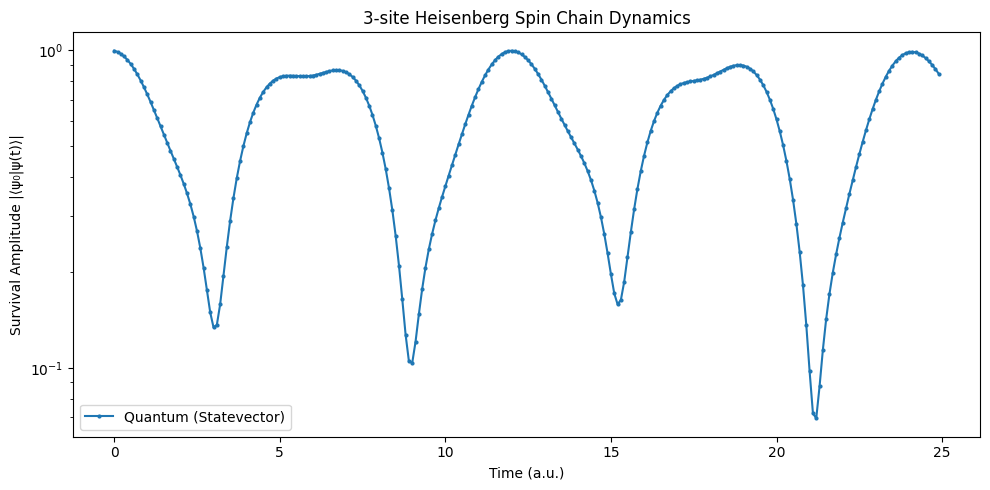

In [7]:
# ============================================================
# Script 4.33–4.34 (Updated): Statevector Experiment
# ============================================================
# PERUBAHAN UTAMA Qiskit 2.x:
# - execute() DIHAPUS → gunakan Statevector(qc) atau AerSimulator
# - BasicAer DIHAPUS → gunakan qiskit_aer.AerSimulator

from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def qsolve_statevector(psin_arr, time_evo_circuit):
    """
    Satu langkah propagasi via statevector simulation.
    
    Pipeline:
    1. Buat circuit baru dengan prepare_state(psin)
    2. Append time_evo_circuit
    3. Hitung statevector akhir
    
    Qiskit 2.x: Statevector(qc) adalah cara paling efisien
    (tidak perlu backend, tidak perlu execute())
    """
    n = len(psin_arr)
    d = int(np.log2(n))

    qre  = QuantumRegister(d)
    circ = QuantumCircuit(qre)
    # prepare_state: pengganti .initialize() yang deprecated
    circ.prepare_state(psin_arr.tolist(), qre)
    circ.barrier()
    circ.append(time_evo_circuit, qre)
    circ.barrier()

    # Hitung statevector (linear algebra, exact, no shots)
    return np.array(Statevector(circ))


# --- Jalankan dinamika ---
nsteps          = 250
evolution_timestep = 0.1

# Dapatkan time evolution operator
time_evo_op = get_time_evolution_operator(
    num_qubits=num_q,
    tau=evolution_timestep,
    trotter_steps=1,
    coeff=ham_coeffs
)

psin_current = psin0.copy()
correlation_list = []

print(f"Menjalankan {nsteps} langkah dinamika spin chain...")
for k in range(nsteps):
    if k % 50 == 0:
        print(f"  Step {k}/{nsteps}")
    psin_current = qsolve_statevector(psin_current, time_evo_op)
    # Survival amplitude: |⟨ψ₀|ψ(t)⟩| = |overlap dengan state awal|
    correlation_list.append(np.vdot(psin_current, psin0))

t              = np.arange(nsteps) * evolution_timestep
sa_observable  = np.abs(correlation_list)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, sa_observable, '-o', markersize=2, label='Quantum (Statevector)')
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Survival Amplitude |⟨ψ₀|ψ(t)⟩|')
ax.set_yscale('log')
ax.set_title(f'3-site Heisenberg Spin Chain Dynamics')
ax.legend()
plt.tight_layout()
plt.show()